# Matplotlib & Seaborn Visualization Cheat Sheet

## Plot Selection Guide

| Chart Type | Best Used For | Matplotlib Code | Seaborn Code |
| :--- | :--- | :--- | :--- |
| **Line Plot** | Trends over time / continuous ordered data | `plt.plot(x, y)` | `sns.lineplot(x=x, y=y)` |
| **Scatter Plot** | Relationship / correlation between 2 continuous variables | `plt.scatter(x, y)` | `sns.scatterplot(x=x, y=y, hue=c)` |
| **Bar Chart** | Comparing discrete categories | `plt.bar(x, height)` | `sns.barplot(x=x, y=y)` |
| **Histogram** | Distribution of a single continuous variable | `plt.hist(data, bins=20)` | `sns.histplot(data, bins=20)` |
| **KDE Plot** | Smooth density estimate of a continuous variable | N/A (requires SciPy) | `sns.kdeplot(data)` |
| **Box Plot** | Distribution summary (quartiles, outliers) across categories | `plt.boxplot(data)` | `sns.boxplot(x=cat, y=num)` |
| **Violin Plot** | Combined distribution density and box plot | `plt.violinplot(data)` | `sns.violinplot(x=cat, y=num)` |
| **Heatmap** | Matrix data, correlation matrices, 2D density | `plt.imshow(matrix)` | `sns.heatmap(matrix, annot=True)` |
| **Count Plot** | Frequency count of categorical variables | N/A (manual binning) | `sns.countplot(x=cat)` |
| **Pair Plot** | Pairwise relationships across all numeric variables | N/A | `sns.pairplot(df)` |

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Load sample dataset
df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 1. Line Plot
**When to use:** Tracking trends or changes over continuous or sequential variables (e.g., time, size, steps).

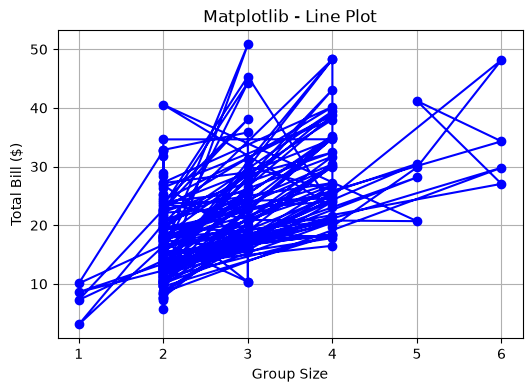

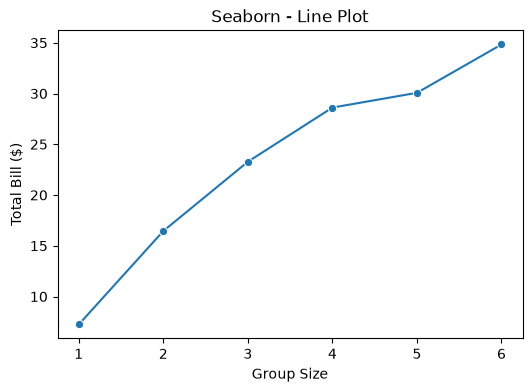

In [2]:
# Matplotlib
plt.figure(figsize=(6, 4))
plt.plot(df["size"], df["total_bill"], marker='o', color='b')
plt.title("Matplotlib - Line Plot")
plt.xlabel("Group Size")
plt.ylabel("Total Bill ($)")
plt.grid(True)
plt.show()

# Seaborn
plt.figure(figsize=(6, 4))
sns.lineplot(data=df, x="size", y="total_bill", errorbar=None, marker='o')
plt.title("Seaborn - Line Plot")
plt.xlabel("Group Size")
plt.ylabel("Total Bill ($)")
plt.show()

## 2. Scatter Plot
**When to use:** Investigating relationships, patterns, or correlations between two continuous variables.

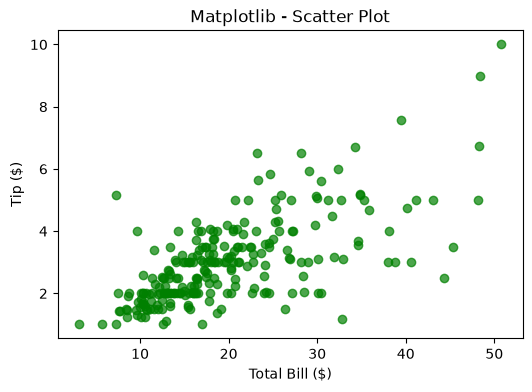

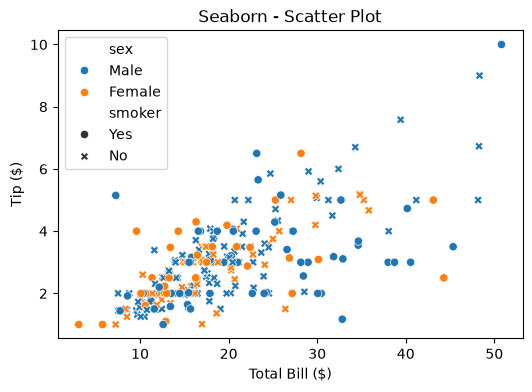

In [4]:
# Matplotlib
plt.figure(figsize=(6, 4))
plt.scatter(df["total_bill"], df["tip"], alpha=0.7, c='green')
plt.title("Matplotlib - Scatter Plot")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.show()

# Seaborn
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="total_bill", y="tip", hue="sex", style="smoker")
plt.title("Seaborn - Scatter Plot")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.show()

## 3. Bar Plot
**When to use:** Comparing numeric aggregations (mean, sum) across distinct categories.

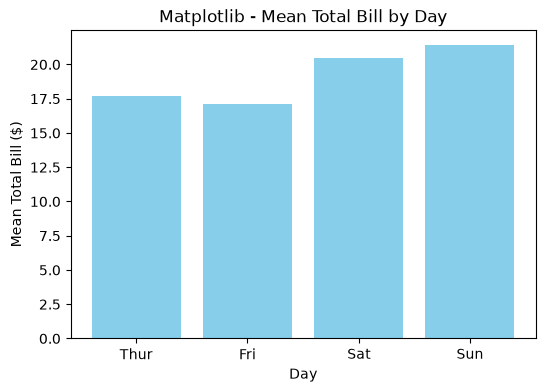

/var/folders/lv/p9vlph914d5554g_z5tcrsdm0000gn/T/ipykernel_1096/2902738798.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="day", y="total_bill", estimator="mean", palette="Blues_d", errorbar=None)


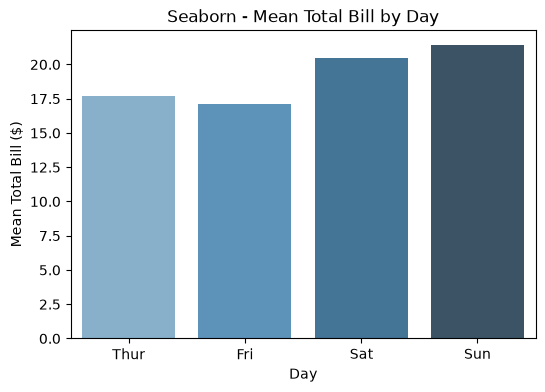

In [5]:
# Matplotlib
means = df.groupby("day", observed=False)["total_bill"].mean()
plt.figure(figsize=(6, 4))
plt.bar(means.index, means.values, color='skyblue')
plt.title("Matplotlib - Mean Total Bill by Day")
plt.xlabel("Day")
plt.ylabel("Mean Total Bill ($)")
plt.show()

# Seaborn
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x="day", y="total_bill", estimator="mean", palette="Blues_d", errorbar=None)
plt.title("Seaborn - Mean Total Bill by Day")
plt.xlabel("Day")
plt.ylabel("Mean Total Bill ($)")
plt.show()

## 4. Histogram & Density (KDE)
**When to use:** Visualizing the frequency distribution and spread of a single continuous variable.

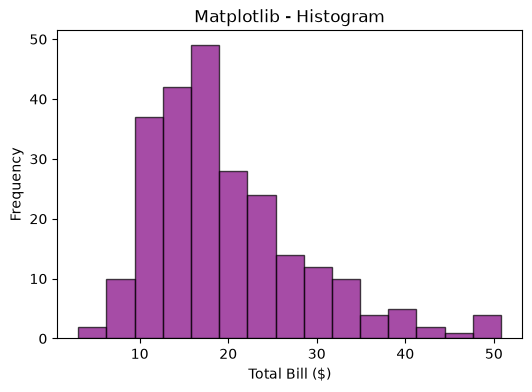

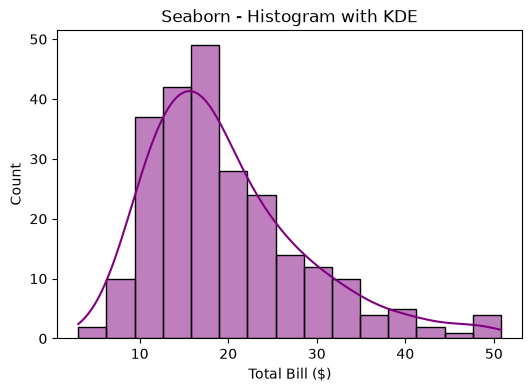

In [5]:
# Matplotlib
plt.figure(figsize=(6, 4))
plt.hist(df["total_bill"], bins=15, color='purple', alpha=0.7, edgecolor='black')
plt.title("Matplotlib - Histogram")
plt.xlabel("Total Bill ($)")
plt.ylabel("Frequency")
plt.show()

# Seaborn (Histogram + KDE)
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x="total_bill", kde=True, bins=15, color='purple')
plt.title("Seaborn - Histogram with KDE")
plt.xlabel("Total Bill ($)")
plt.ylabel("Count")
plt.show()

## 5. Box Plot & Violin Plot
**When to use:** Comparing distributions across multiple categories, identifying median values, quartiles, and outliers.

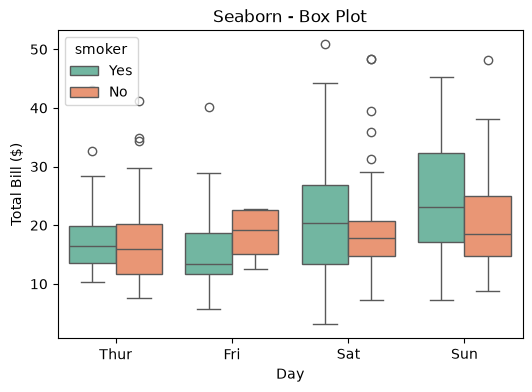

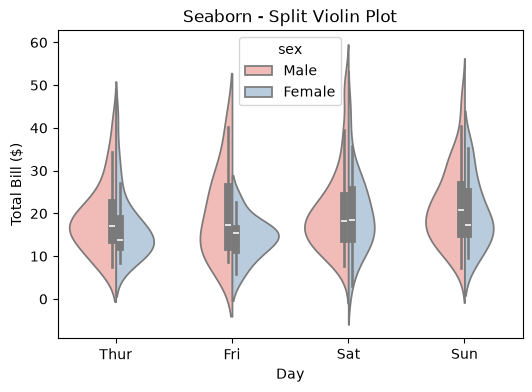

In [6]:
# Seaborn Box Plot
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="day", y="total_bill", hue="smoker", palette="Set2")
plt.title("Seaborn - Box Plot")
plt.xlabel("Day")
plt.ylabel("Total Bill ($)")
plt.show()

# Seaborn Violin Plot
plt.figure(figsize=(6, 4))
sns.violinplot(data=df, x="day", y="total_bill", hue="sex", split=True, palette="Pastel1")
plt.title("Seaborn - Split Violin Plot")
plt.xlabel("Day")
plt.ylabel("Total Bill ($)")
plt.show()

## 6. Heatmap
**When to use:** Representing matrix-like data, such as correlation matrices or 2D density distributions.

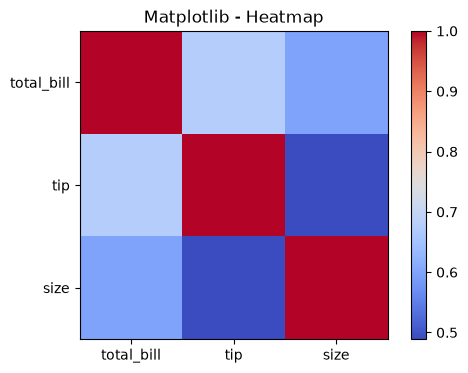

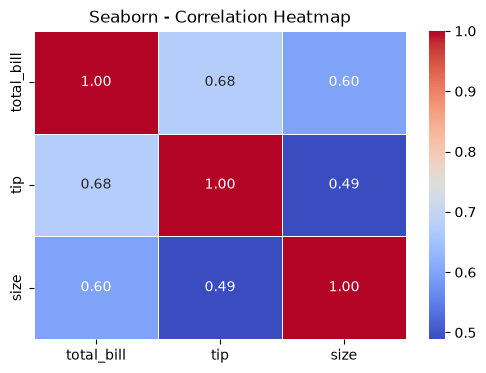

In [7]:
corr = df.corr(numeric_only=True)

# Matplotlib
plt.figure(figsize=(6, 4))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns)
plt.yticks(range(len(corr)), corr.columns)
plt.title("Matplotlib - Heatmap")
plt.show()

# Seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Seaborn - Correlation Heatmap")
plt.show()